# Majorana Demonstrator — Data Visualization

A first look at the public Majorana Demonstrator AI/ML data release
(arXiv:2308.10856, Zenodo DOI 10.5281/zenodo.8257027).

This notebook does **not** train any model. The goals are:

1. Catalog the HDF5 files on disk and their sizes.
2. Confirm the schema of one file (keys, shapes, dtypes).
3. Measure load time for the major fields (waveforms vs. scalars).
4. Print summary statistics for energies, detectors, runs, and PSD labels.
5. Plot a few standard quantities — sample waveforms, energy spectrum,
   PSD-cut survival, per-detector event counts, and the `tp0` distribution.

**Kernel**: this notebook expects the project virtualenv at
`/home/yuema137/MAJORANA_ACP/.venv/bin/python`.
Run `uv sync` once from the project root to install dependencies.


## 1. Setup

In [1]:
from __future__ import annotations

import time
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path("/home/klz/Data/MAJORANA")

assert DATA_DIR.is_dir(), f"Data directory not found: {DATA_DIR}"

plt.rcParams["figure.dpi"] = 110


## 2. File Inventory

Group the `.hdf5` files by split (`Train` / `Test` / `NPML`) and report total
on-disk size. The Zenodo partial release is expected to contain 16 train,
6 test, and 3 NPML files, ~45 GB in total.


In [2]:
files = sorted(DATA_DIR.glob("*.hdf5"))

splits: dict[str, list[Path]] = {"Train": [], "Test": [], "NPML": []}
for f in files:
    for k in splits:
        if f"MJD_{k}_" in f.name:
            splits[k].append(f)
            break

total_bytes = sum(f.stat().st_size for f in files)
print(f"Found {len(files)} HDF5 files, {total_bytes / 1e9:.2f} GB total\n")
for k, fs in splits.items():
    sub = sum(f.stat().st_size for f in fs)
    print(f"  {k:5s}: {len(fs):2d} files, {sub / 1e9:5.2f} GB")


Found 25 HDF5 files, 48.39 GB total

  Train: 16 files, 31.66 GB
  Test :  6 files, 11.87 GB
  NPML :  3 files,  4.86 GB


## 3. HDF5 Schema

Each file is a flat collection of parallel arrays (one entry per event).
The expected fields per the data release paper (Table I) are:

| Field | Description | Dtype |
|---|---|---|
| `raw_waveform` | Detector waveform, 3800 samples | float |
| `energy_label` | Calibrated energy in keV | float |
| `psd_label_low_avse` | AvsE low-side multi-site cut | bool |
| `psd_label_high_avse` | AvsE high-side surface cut | bool |
| `psd_label_dcr` | Delayed-charge-recovery α cut | bool |
| `psd_label_lq` | Late-charge transition-layer cut | bool |
| `tp0` | Index of rising-edge start | int |
| `detector` | Unique detector ID (CPD encoding) | int |
| `run_number` | Calibration run ID | int |
| `id` | Global unique event ID | int |

For each PSD label, `1` means the event passed (kept) and `0` means
rejected. A "clean" event passes **all four** cuts simultaneously.


In [3]:
sample_file = splits["Train"][0]

with h5py.File(sample_file, "r") as f:
    print(f"File: {sample_file.name}\n")
    for k in f.keys():
        d = f[k]
        print(f"  {k:25s} shape={str(d.shape):15s} dtype={d.dtype}")


File: MJD_Train_0.hdf5

  detector                  shape=(65000,)        dtype=int64
  energy_label              shape=(65000,)        dtype=float64
  id                        shape=(65000,)        dtype=int64
  psd_label_dcr             shape=(65000,)        dtype=bool
  psd_label_high_avse       shape=(65000,)        dtype=bool
  psd_label_low_avse        shape=(65000,)        dtype=bool
  psd_label_lq              shape=(65000,)        dtype=bool
  raw_waveform              shape=(65000, 3800)   dtype=float64
  run_number                shape=(65000,)        dtype=int64
  tp0                       shape=(65000,)        dtype=int64


## 4. Loading and Timing

Read the major fields from a single file and time each operation.
The waveform array dominates the file size (~1.85 GB / 65 000 events),
so it is the dominant I/O cost.

We also load every field into NumPy arrays so the rest of the notebook
can plot from memory without re-opening the file.


In [4]:
def time_it(label: str, fn):
    t0 = time.perf_counter()
    out = fn()
    dt = time.perf_counter() - t0
    nbytes = getattr(out, "nbytes", 0)
    rate = f" ({nbytes / dt / 1e9:.2f} GB/s)" if nbytes > 1e7 else ""
    print(f"  {label:30s} {dt*1000:7.1f} ms{rate}")
    return out


print(f"Reading {sample_file.name}\n")
with h5py.File(sample_file, "r") as f:
    waveforms = time_it("raw_waveform [all]", lambda: f["raw_waveform"][:])
    energy = time_it("energy_label [all]", lambda: f["energy_label"][:])
    detector = time_it("detector [all]", lambda: f["detector"][:])
    run_number = time_it("run_number [all]", lambda: f["run_number"][:])
    tp0 = time_it("tp0 [all]", lambda: f["tp0"][:])
    psd = {
        k: time_it(f"psd_label_{k} [all]", lambda key=k: f[f"psd_label_{key}"][:])
        for k in ("low_avse", "high_avse", "dcr", "lq")
    }

    rng = np.random.default_rng(0)
    idx = np.sort(rng.choice(len(energy), 1000, replace=False))
    _ = time_it("raw_waveform [1000 random]", lambda: f["raw_waveform"][idx])

n_events = len(energy)
clean = psd["low_avse"] & psd["high_avse"] & psd["dcr"] & psd["lq"]

print(f"\n{n_events} events loaded.")
print(f"Waveforms in memory: {waveforms.nbytes / 1e9:.2f} GB "
      f"(shape={waveforms.shape}, dtype={waveforms.dtype})")


Reading MJD_Train_0.hdf5

  raw_waveform [all]               517.7 ms (3.82 GB/s)
  energy_label [all]                 0.8 ms
  detector [all]                     0.4 ms
  run_number [all]                   0.4 ms
  tp0 [all]                          0.3 ms
  psd_label_low_avse [all]           0.3 ms
  psd_label_high_avse [all]          0.2 ms
  psd_label_dcr [all]                0.2 ms
  psd_label_lq [all]                 0.2 ms
  raw_waveform [1000 random]        13.4 ms (2.27 GB/s)

65000 events loaded.
Waveforms in memory: 1.98 GB (shape=(65000, 3800), dtype=float64)


## 5. Field Statistics

Quick numerical summary of each field for the loaded file.


In [5]:
print(f"Energy [keV]    : min={energy.min():8.2f}  max={energy.max():8.2f}  "
      f"mean={energy.mean():8.2f}  median={np.median(energy):8.2f}")
print(f"tp0 [sample idx]: min={tp0.min():8d}  max={tp0.max():8d}  "
      f"mean={tp0.mean():8.1f}")
print(f"Detectors       : {len(np.unique(detector)):d} unique IDs")
print(f"Runs            : {len(np.unique(run_number)):d} unique runs")

print("\nPSD label pass rates (this file only):")
for k, mask in psd.items():
    print(f"  psd_label_{k:10s}: {mask.mean() * 100:5.2f}% pass  "
          f"({mask.sum():>6d} / {n_events})")
print(f"  ALL 4 cuts            : {clean.mean() * 100:5.2f}% pass  "
      f"({clean.sum():>6d} / {n_events})")


Energy [keV]    : min=    1.52  max= 3220.31  mean=  633.39  median=  339.53
tp0 [sample idx]: min=     146  max=    1183  mean=   951.6
Detectors       : 26 unique IDs
Runs            : 50 unique runs

PSD label pass rates (this file only):
  psd_label_low_avse  : 44.75% pass  ( 29085 / 65000)
  psd_label_high_avse : 99.16% pass  ( 64455 / 65000)
  psd_label_dcr       : 98.11% pass  ( 63773 / 65000)
  psd_label_lq        : 70.80% pass  ( 46022 / 65000)
  ALL 4 cuts            : 38.15% pass  ( 24798 / 65000)


## 6. Visualizations

### 6.1 Sample Waveforms

Four randomly-selected waveforms with the rising-edge start `tp0` marked.
The x-axis is the sample index (10 ns per sample after the recovery of
pre-summed regions).


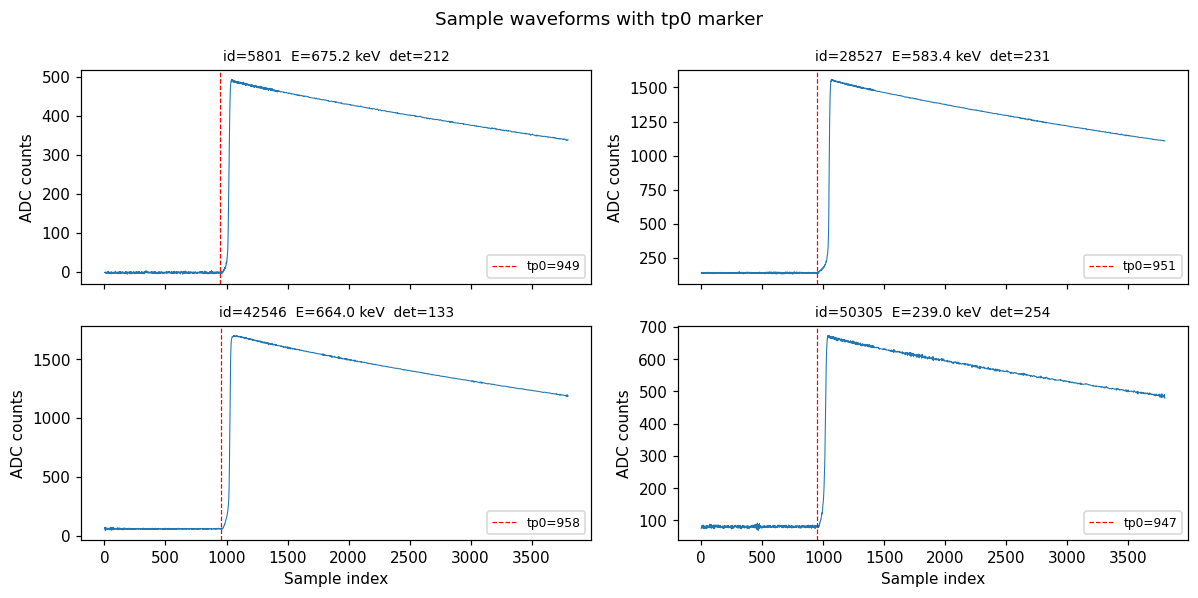

In [6]:
rng = np.random.default_rng(42)
sample_idx = np.sort(rng.choice(n_events, 4, replace=False))

fig, axes = plt.subplots(2, 2, figsize=(11, 5.5), sharex=True)
for ax, i in zip(axes.flat, sample_idx):
    ax.plot(waveforms[i], lw=0.7)
    ax.axvline(tp0[i], color="red", ls="--", lw=0.8, label=f"tp0={tp0[i]}")
    ax.set_title(f"id={i}  E={energy[i]:.1f} keV  det={detector[i]}", fontsize=9)
    ax.set_ylabel("ADC counts")
    ax.legend(loc="lower right", fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel("Sample index")
fig.suptitle("Sample waveforms with tp0 marker")
fig.tight_layout()
plt.show()


### 6.2 Energy Spectrum

The full energy spectrum of this file vs. the survival spectrum after all
four PSD cuts. Reproduces the structure of Figure 2 in the data-release
paper (on a single file rather than the full dataset). The step-like
feature near 100 keV is from the upstream `sumE > 100 keV` skim cut.


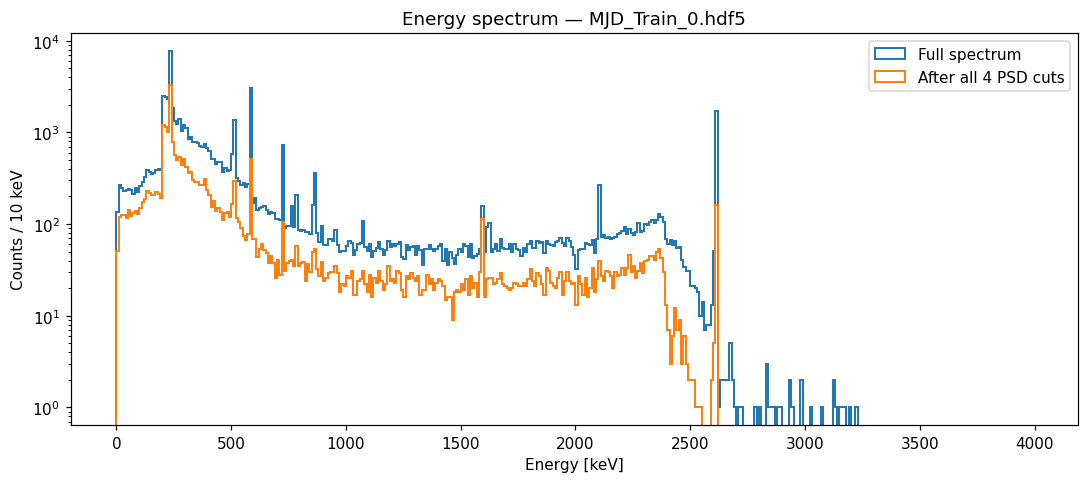

In [7]:
bins = np.arange(0, 4000, 10)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(energy, bins=bins, histtype="step", lw=1.3, label="Full spectrum")
ax.hist(energy[clean], bins=bins, histtype="step", lw=1.3,
        label="After all 4 PSD cuts")
ax.set_yscale("log")
ax.set_xlabel("Energy [keV]")
ax.set_ylabel("Counts / 10 keV")
ax.set_title(f"Energy spectrum — {sample_file.name}")
ax.legend()
fig.tight_layout()
plt.show()


### 6.3 PSD Cut Survival

Per-cut and combined pass rates for this file. The product of marginal
pass rates is **not** the joint pass rate because the cuts are
correlated.


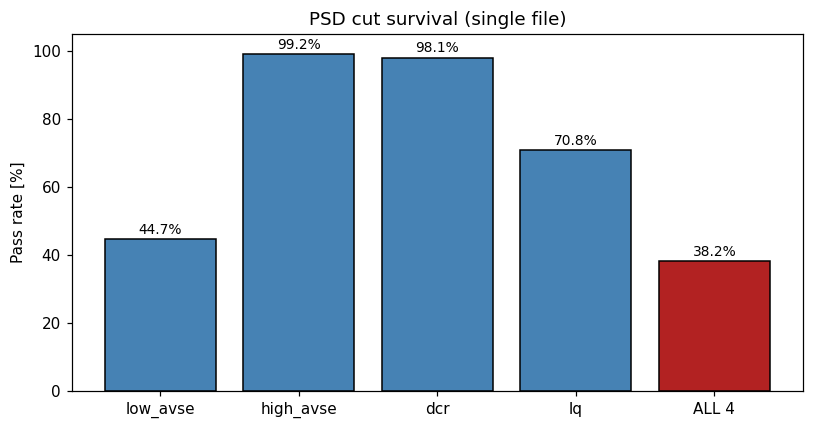

In [8]:
labels = ["low_avse", "high_avse", "dcr", "lq", "ALL 4"]
rates = [psd["low_avse"].mean(), psd["high_avse"].mean(),
         psd["dcr"].mean(), psd["lq"].mean(), clean.mean()]
rates = [r * 100 for r in rates]

fig, ax = plt.subplots(figsize=(7.5, 4))
bars = ax.bar(labels, rates, color=["steelblue"] * 4 + ["firebrick"],
              edgecolor="k")
ax.set_ylabel("Pass rate [%]")
ax.set_title("PSD cut survival (single file)")
ax.set_ylim(0, 105)
for bar, r in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width() / 2, r + 1.5, f"{r:.1f}%",
            ha="center", fontsize=9)
fig.tight_layout()
plt.show()


### 6.4 Events per Detector

The detector ID encodes the physical position (CPD = Cryostat-Position-Detector,
e.g., `272` is C2P7D2). Event counts vary per detector because of differing
exposure, efficiency, and threshold.


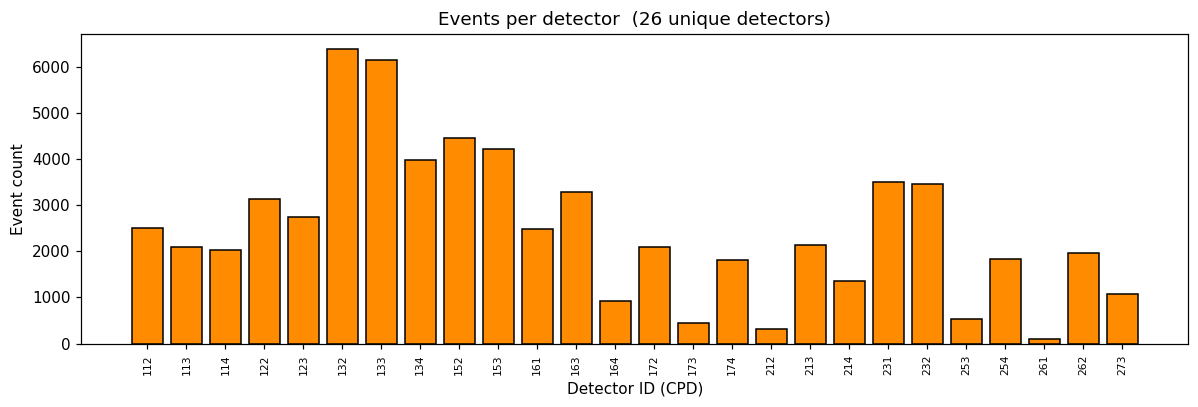

In [9]:
det_unique, det_counts = np.unique(detector, return_counts=True)

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.bar(np.arange(len(det_unique)), det_counts,
       color="darkorange", edgecolor="k")
ax.set_xticks(np.arange(len(det_unique)))
ax.set_xticklabels([str(d) for d in det_unique], rotation=90, fontsize=7)
ax.set_xlabel("Detector ID (CPD)")
ax.set_ylabel("Event count")
ax.set_title(f"Events per detector  ({len(det_unique)} unique detectors)")
fig.tight_layout()
plt.show()


### 6.5 `tp0` Distribution

`tp0` is the sample index where the rising edge starts (estimated via an
asymmetric trapezoidal filter). It should cluster near a fixed location
within each waveform; the spread tells us how aligned the events are.


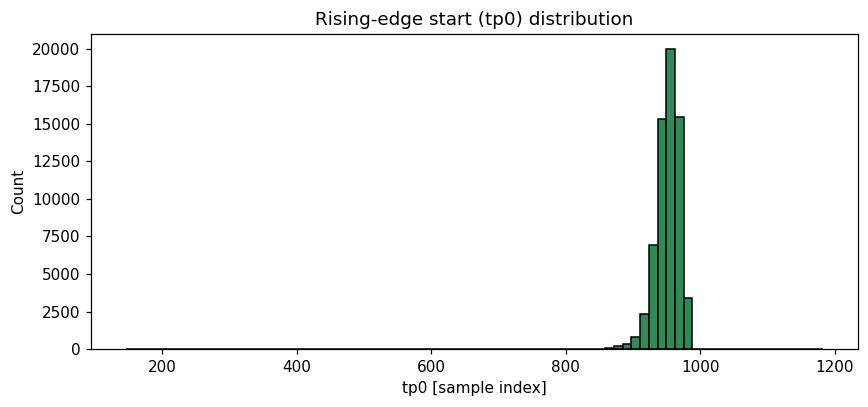

In [10]:
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.hist(tp0, bins=80, color="seagreen", edgecolor="k")
ax.set_xlabel("tp0 [sample index]")
ax.set_ylabel("Count")
ax.set_title("Rising-edge start (tp0) distribution")
fig.tight_layout()
plt.show()


### 6.6 `low_avse` Acceptance vs Energy

Pass rate of the `psd_label_low_avse` cut, binned in energy. The cut is
designed to reject low-AvsE multi-site backgrounds, so its acceptance is
energy-dependent — single-site signal events at the 2615 keV ²⁰⁸Tl
photo-peak should sit close to 1, while events in the multi-site Compton
continuum sit lower.

Vertical error bars are the binomial standard error
`sqrt(p*(1-p)/N)`. Bins with few events are visibly noisier.


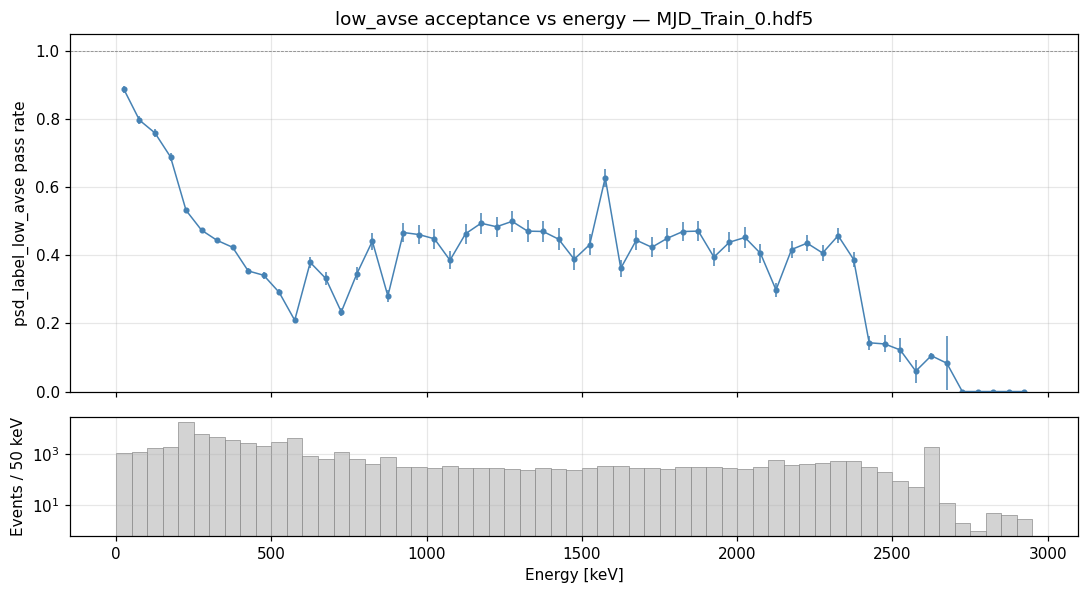

In [11]:
e_bins = np.arange(0, 3000, 50)
e_centers = 0.5 * (e_bins[:-1] + e_bins[1:])

total, _ = np.histogram(energy, bins=e_bins)
passed, _ = np.histogram(energy[psd["low_avse"]], bins=e_bins)

rate = np.divide(
    passed, total,
    out=np.full(total.shape, np.nan, dtype=float),
    where=total > 0,
)
err = np.where(total > 0,
               np.sqrt(rate * (1 - rate) / np.maximum(total, 1)),
               0.0)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(10, 5.5), sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)

ax_top.errorbar(e_centers, rate, yerr=err, fmt="o-",
                lw=1, ms=3, color="steelblue")
ax_top.axhline(1.0, color="gray", lw=0.5, ls="--")
ax_top.set_ylabel("psd_label_low_avse pass rate")
ax_top.set_ylim(0, 1.05)
ax_top.set_title(f"low_avse acceptance vs energy — {sample_file.name}")
ax_top.grid(True, alpha=0.3)

ax_bot.bar(e_centers, total, width=np.diff(e_bins),
           color="lightgray", edgecolor="gray", lw=0.4)
ax_bot.set_yscale("log")
ax_bot.set_xlabel("Energy [keV]")
ax_bot.set_ylabel("Events / 50 keV")
ax_bot.grid(True, alpha=0.3, which="both")

fig.tight_layout()
plt.show()


## 7. Preprocessed Waveforms

Up to here we plotted the raw HDF5 waveforms. The model will instead
see the *preprocessed* waveform — what `majorana_acp.data.MajoranaWaveformDataset`
yields. The preprocessing recipe (CLAUDE.md, "Current Task") is:

1. Subtract baseline = mean of the first 500 samples.
2. Divide by the max of the baseline-subtracted waveform.
3. Cast to `float32`.

After this step every waveform has baseline ≈ 0 and peak == 1.0,
so 10 overlaid events have a directly comparable shape.


### 7.1 Random sample

Ten randomly-selected preprocessed waveforms (no class filtering).


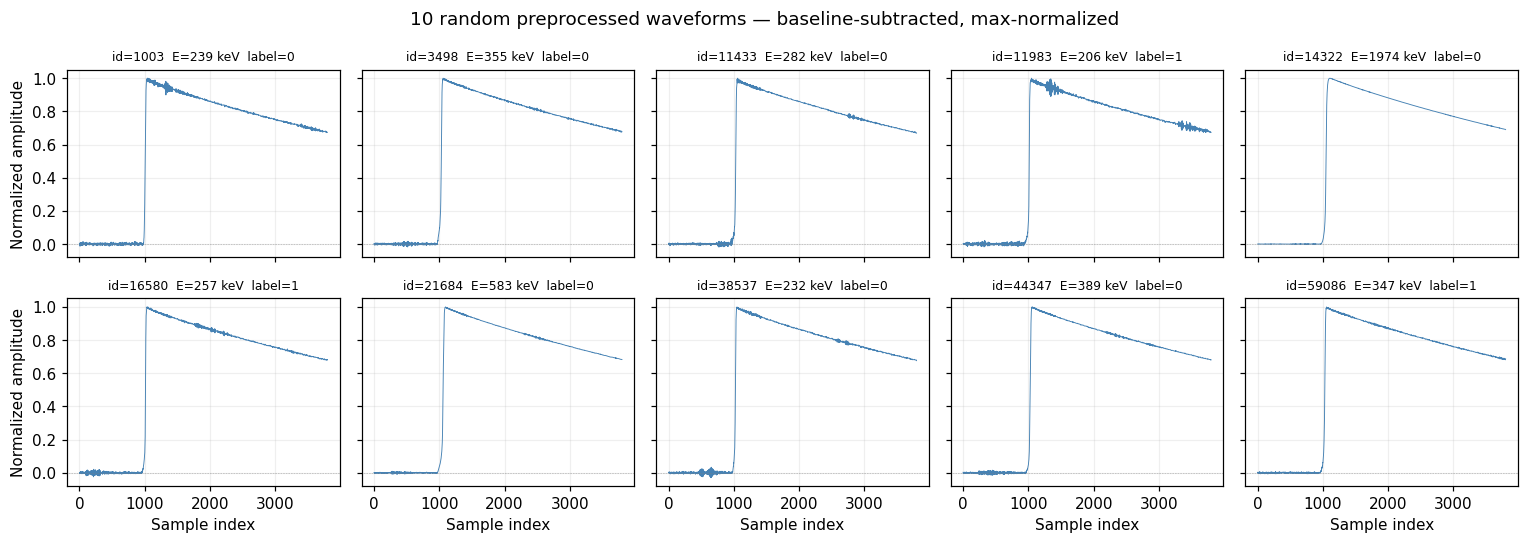

In [12]:
from majorana_acp.data import DatasetConfig, MajoranaWaveformDataset

ds = MajoranaWaveformDataset(DatasetConfig(files=[sample_file]))

rng = np.random.default_rng(123)
plot_idx = np.sort(rng.choice(len(ds), 10, replace=False))

fig, axes = plt.subplots(2, 5, figsize=(14, 5), sharex=True, sharey=True)
for ax, i in zip(axes.flat, plot_idx):
    item = ds[int(i)]
    wf = item["waveform"].numpy()
    ax.plot(wf, lw=0.6, color="steelblue")
    ax.axhline(0.0, color="gray", lw=0.4, ls=":")
    ax.set_title(
        f"id={item['id'].item()}  E={item['energy'].item():.0f} keV  "
        f"label={int(item['label'].item())}",
        fontsize=8,
    )
    ax.grid(True, alpha=0.2)

for ax in axes[-1]:
    ax.set_xlabel("Sample index")
for ax in axes[:, 0]:
    ax.set_ylabel("Normalized amplitude")

fig.suptitle("10 random preprocessed waveforms — baseline-subtracted, max-normalized")
fig.tight_layout()
plt.show()


### 7.2 Comparison by class: `psd_label_low_avse == 0` vs `== 1`

Stratified by the target label so the model's job becomes visually
obvious. To control for energy as a confounder we restrict to events
with **1500 keV < energy < 2000 keV** (between the ²¹²Bi 1621 keV
peak and the ²⁰⁸Tl 2615 keV double-escape region — a band where
single-site signal events and multi-site Compton-continuum events
meaningfully coexist).

* **Top row** — 5 events with `psd_label_low_avse == 0` (rejected by the cut).
* **Bottom row** — 5 events with `psd_label_low_avse == 1` (passed).

If a structural difference is visible by eye between the two rows
within this energy band, that is the signal a translation-invariant
model should be able to learn.


Events in 1500-2000 keV band:
  label=0 (rejected):  1644 available
  label=1 (passed)  :  1362 available



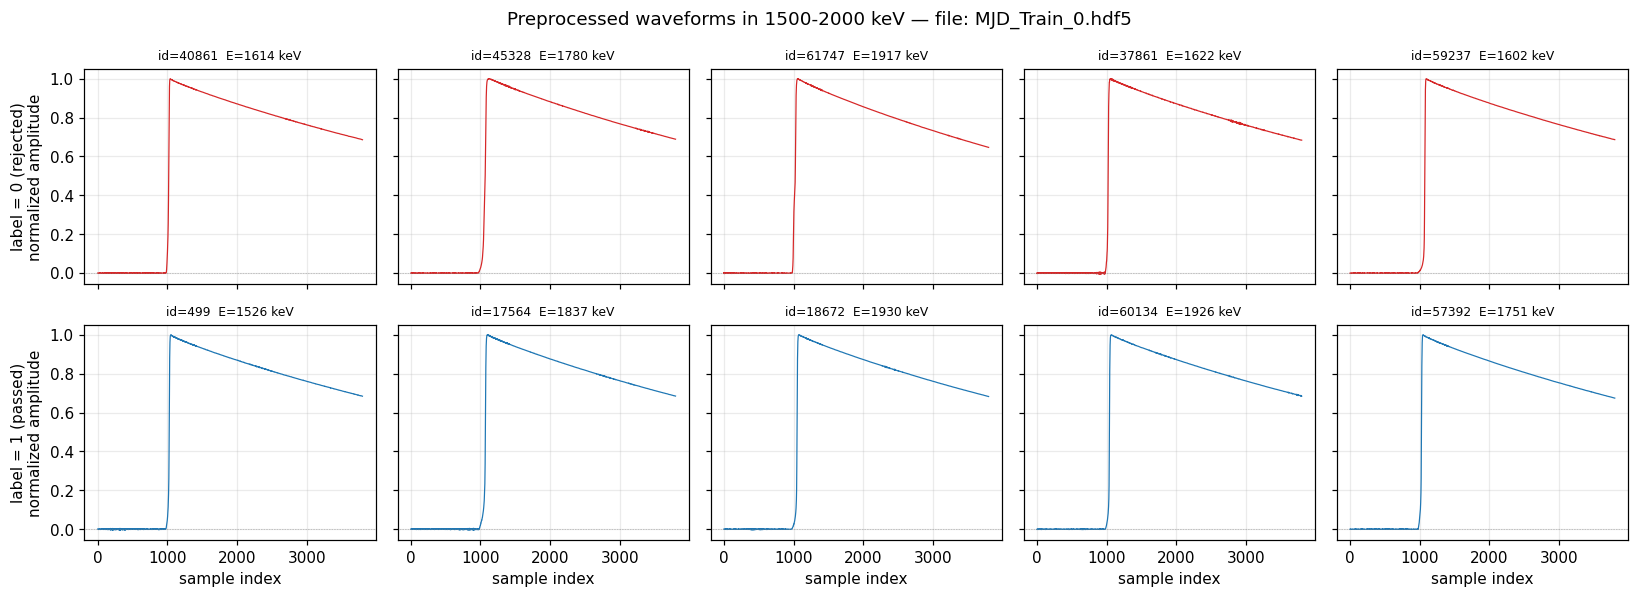

In [13]:
import h5py as _h5py

# Read labels + energies directly from the HDF5 file.
with _h5py.File(sample_file, "r") as _f:
    _labels = _f["psd_label_low_avse"][:].astype(bool)
    _energy = _f["energy_label"][:]

# Energy band: 1500 < E < 2000 keV.
_in_band = (_energy > 1500.0) & (_energy < 2000.0)

_idx_fail = np.where(~_labels & _in_band)[0]   # label=0 in band
_idx_pass = np.where(_labels & _in_band)[0]    # label=1 in band

print(f"Events in 1500-2000 keV band:")
print(f"  label=0 (rejected): {len(_idx_fail):5d} available")
print(f"  label=1 (passed)  : {len(_idx_pass):5d} available\n")

_n_per_class = 5
_rng = np.random.default_rng(7)
_sel_fail = _rng.choice(_idx_fail, size=min(_n_per_class, len(_idx_fail)), replace=False)
_sel_pass = _rng.choice(_idx_pass, size=min(_n_per_class, len(_idx_pass)), replace=False)

_ds_cmp = MajoranaWaveformDataset(DatasetConfig(files=[sample_file]))

fig, axes = plt.subplots(2, 5, figsize=(15, 5.5), sharex=True, sharey=True)
for ax, i in zip(axes[0], _sel_fail):
    item = _ds_cmp[int(i)]
    ax.plot(item["waveform"].numpy(), lw=0.8, color="tab:red")
    ax.axhline(0.0, color="gray", lw=0.4, ls=":")
    ax.set_title(
        f"id={item['id'].item()}  E={item['energy'].item():.0f} keV", fontsize=8
    )
    ax.grid(alpha=0.25)
for ax, i in zip(axes[1], _sel_pass):
    item = _ds_cmp[int(i)]
    ax.plot(item["waveform"].numpy(), lw=0.8, color="tab:blue")
    ax.axhline(0.0, color="gray", lw=0.4, ls=":")
    ax.set_title(
        f"id={item['id'].item()}  E={item['energy'].item():.0f} keV", fontsize=8
    )
    ax.grid(alpha=0.25)

axes[0, 0].set_ylabel("label = 0 (rejected)\nnormalized amplitude")
axes[1, 0].set_ylabel("label = 1 (passed)\nnormalized amplitude")
for ax in axes[1]:
    ax.set_xlabel("sample index")

fig.suptitle(
    f"Preprocessed waveforms in 1500-2000 keV — file: {sample_file.name}"
)
fig.tight_layout()
plt.show()


## 8. Training Results & Model Comparison

Each call to `python -m majorana_acp.cli.train …` produces a directory
under `runs/<name>/` containing:

| File | Contents |
|---|---|
| `metadata.json` | Full config + runtime info (git SHA, host, versions, start/end time, completed epochs, final metrics) |
| `training_history.json` | Per-epoch `train_loss`, `test_loss`, `test_roc_auc` |
| `epoch_NNN.pt` | Model + optimizer checkpoint per epoch |
| `train.log` | Training log scoped to the run |
| `eval/predictions.h5` | (If `evaluate` was run) raw test scores, logits, labels, and aux fields |
| `eval/metrics.json` | (If `evaluate` was run) scalar metrics |

This section discovers all runs, plots loss curves and ROC curves, and
renders a side-by-side comparison table.


In [14]:
import json
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve as sk_roc_curve

# Locate runs/ regardless of whether the notebook is launched from the
# project root or from notebooks/.
for _candidate in (Path("runs"), Path("../runs")):
    if _candidate.is_dir():
        RUNS_DIR = _candidate.resolve()
        break
else:
    raise FileNotFoundError("Could not locate runs/ directory")

# Filter discovery to specific subfolders (groups) of runs/.
# - None       : load every run found anywhere under runs/
# - []         : same as None (no filter)
# - ["full_data_configs"]                     : just the full-data runs
# - ["full_data_configs", "small_data_configs"]  : combine groups
# Loose top-level runs (no subfolder) match the empty-string group "".
GROUPS: list[str] | None = ["full_data_configs"]

print(f"RUNS_DIR = {RUNS_DIR}")
print(f"GROUPS   = {GROUPS}")


def load_run(run_dir: Path) -> dict | None:
    """Load metadata + history (+ eval predictions if present) for one run."""
    meta_path = run_dir / "metadata.json"
    hist_path = run_dir / "training_history.json"
    if not (meta_path.is_file() and hist_path.is_file()):
        return None

    metadata = json.loads(meta_path.read_text())
    history = json.loads(hist_path.read_text())

    # Group = relative path from RUNS_DIR up to (but excluding) the run dir.
    rel_parent = run_dir.relative_to(RUNS_DIR).parent
    group = "" if rel_parent == Path(".") else str(rel_parent)

    predictions = None
    pred_path = run_dir / "eval" / "predictions.h5"
    if pred_path.is_file():
        with h5py.File(pred_path, "r") as f:
            predictions = {
                "score": f["score"][:],
                "label": f["label"][:].astype(bool),
            }

    return {
        "name": metadata["name"],
        "metadata": metadata,
        "history": history,
        "predictions": predictions,
        "run_dir": run_dir,
        "group": group,
    }


def discover_runs(
    runs_dir: Path, groups: list[str] | None = None
) -> list[dict]:
    """Walk ``runs_dir`` recursively for any directory containing
    metadata.json. Filter by ``groups`` (relative parent paths) when set;
    otherwise return every run found.
    """
    found: list[dict] = []
    for meta_path in sorted(runs_dir.rglob("metadata.json")):
        run = load_run(meta_path.parent)
        if run is None:
            continue
        if groups:  # non-empty list filters
            if run["group"] not in groups:
                continue
        found.append(run)
    return found


runs = discover_runs(RUNS_DIR, groups=GROUPS)
print(f"Found {len(runs)} run(s):")
for r in runs:
    has_eval = "yes" if r["predictions"] is not None else "no"
    group_label = r["group"] or "(top-level)"
    print(
        f"  - [{group_label:18s}] {r['name']:30s}  "
        f"epochs={len(r['history']):2d}  eval={has_eval}"
    )


RUNS_DIR = /home/yuema137/MAJORANA_ACP/runs
Found 5 run(s):
  - inception_single               epochs=50  eval=yes
  - mlp_baseline                   epochs=50  eval=yes
  - mlp_v2                         epochs=50  eval=yes
  - resnet_single                  epochs=50  eval=yes
  - simple_cnn_baseline            epochs=50  eval=yes


### 8.1 Loss Curves

Train and test loss as a function of epoch, one curve per run on shared
axes. The test set is held out from training and used purely for
monitoring (no early stopping). Diverging train and test curves indicate
overfitting.


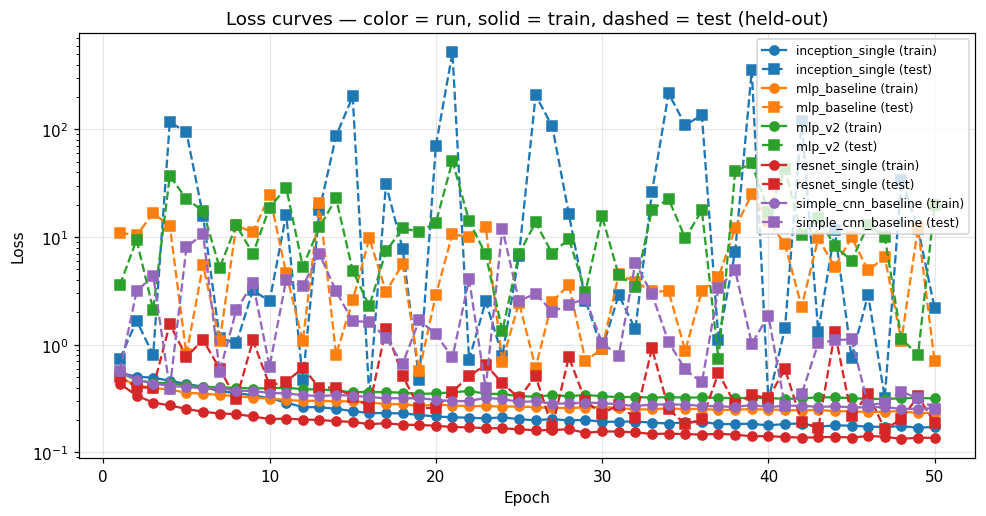

In [15]:
if not runs:
    print("No runs found; skip plotting.")
else:
    palette = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    fig, ax = plt.subplots(figsize=(9, 4.8))
    for i, r in enumerate(runs):
        color = palette[i % len(palette)]
        epochs = [h["epoch"] for h in r["history"]]
        train_loss = [h["train_loss"] for h in r["history"]]
        test_loss = [h["test_loss"] for h in r["history"]]
        ax.plot(
            epochs, train_loss, marker="o", linestyle="-",
            color=color, label=f"{r['name']} (train)",
        )
        ax.plot(
            epochs, test_loss, marker="s", linestyle="--",
            color=color, label=f"{r['name']} (test)",
        )
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title("Loss curves — color = run, solid = train, dashed = test (held-out)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    fig.tight_layout()
    ax.set_yscale("log")
    plt.show()


### 8.2 ROC Curves (final checkpoint)

Full ROC curves built from the saved predictions of each run's `eval/`
output. Runs without an `eval/` directory are skipped — invoke
`python -m majorana_acp.cli.evaluate runs/<name>` first to populate it.


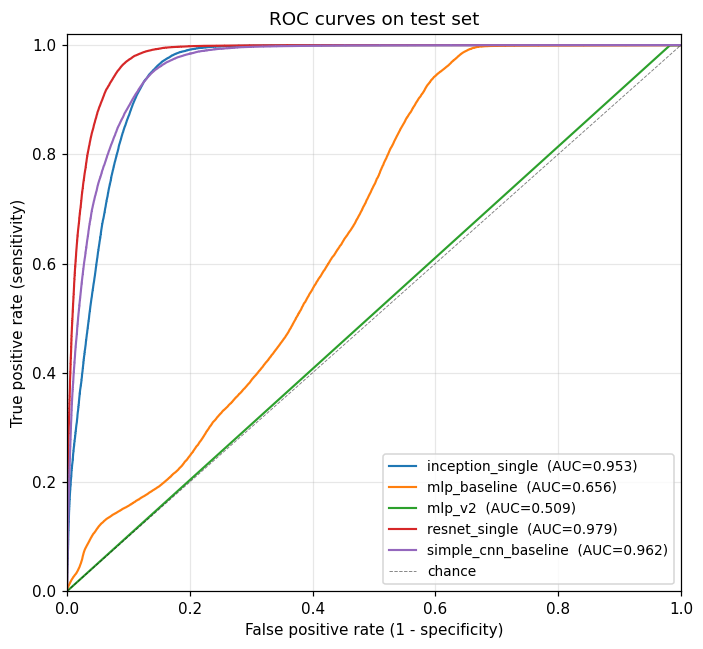

In [16]:
# Read predictions.h5 fresh from disk so newly-evaluated runs are
# picked up without re-running the discovery cell above.
def _load_predictions(run_dir: Path) -> dict | None:
    pred_path = run_dir / "eval" / "predictions.h5"
    if not pred_path.is_file():
        return None
    with h5py.File(pred_path, "r") as f:
        return {"score": f["score"][:], "label": f["label"][:].astype(bool)}


eval_runs = []
for r in runs:
    preds = _load_predictions(r["run_dir"])
    if preds is not None:
        eval_runs.append((r, preds))

if not eval_runs:
    print("No runs have eval/predictions.h5 yet — run "
          "`python -m majorana_acp.cli.evaluate runs/<name>` first.")
else:
    fig, ax = plt.subplots(figsize=(6.5, 6.0))
    for r, preds in eval_runs:
        labels = preds["label"]
        scores = preds["score"]
        if labels.sum() == 0 or labels.sum() == len(labels):
            continue  # single-class — ROC undefined
        fpr, tpr, _ = sk_roc_curve(labels, scores)
        auc = r["history"][-1]["test_roc_auc"] if r["history"] else None
        label = f"{r['name']}  (AUC={auc:.3f})" if auc is not None else r["name"]
        ax.plot(fpr, tpr, lw=1.4, label=label)
    ax.plot([0, 1], [0, 1], "k--", lw=0.6, alpha=0.5, label="chance")
    ax.set_xlabel("False positive rate (1 - specificity)")
    ax.set_ylabel("True positive rate (sensitivity)")
    ax.set_title("ROC curves on test set")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()


### 8.3 Test ROC-AUC Over Epochs

ROC-AUC computed on the held-out test set after each epoch. A model that
is learning the right thing should monotonically improve toward 1.0;
saturation or decline indicates that more capacity, more data, or a
different loss is needed.


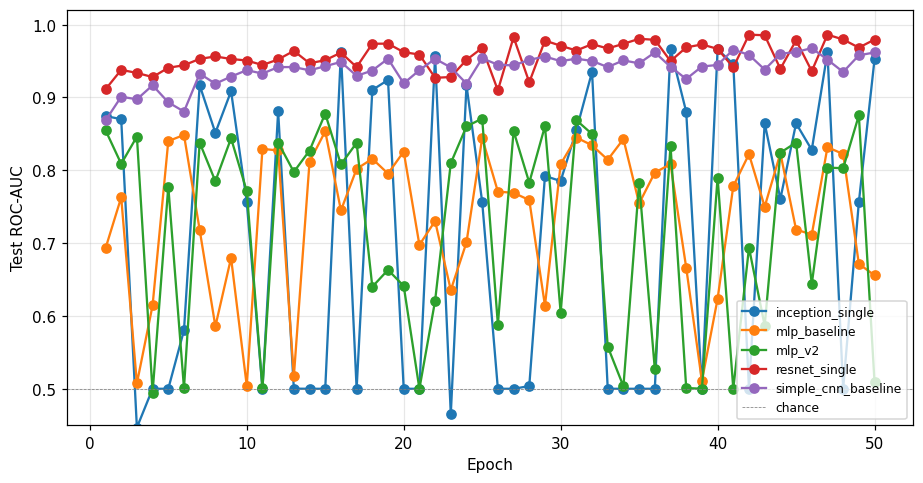

In [17]:
if not runs:
    print("No runs found; skip plotting.")
else:
    fig, ax = plt.subplots(figsize=(8.5, 4.5))
    for r in runs:
        epochs = [h["epoch"] for h in r["history"]]
        aucs = [h["test_roc_auc"] for h in r["history"]]
        if all(a is not None for a in aucs):
            ax.plot(epochs, aucs, marker="o", label=r["name"])
    ax.axhline(0.5, color="gray", lw=0.5, ls="--", label="chance")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Test ROC-AUC")
    ax.set_ylim(0.45, 1.02)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()


### 8.4 Background rejection vs signal acceptance, energy-resolved

Section 8.2's ROC curve summarizes performance with a single number
(the AUC) over all events; this view trades that summary for an
energy-resolved breakdown.

For a chosen threshold ``t``, an event is classified as *passed* when
``score >= t`` and *rejected* when ``score < t``. Treating
``psd_label_low_avse == 0`` as background (multi-site scatter, should
be rejected) and ``== 1`` as signal (single-site scatter, should be
accepted), we plot two rates as a function of energy:

* **Top** — background rejection: fraction of label-0 events the cut
  correctly rejects.
* **Bottom** — signal acceptance: fraction of label-1 events the cut
  correctly accepts.

A perfect classifier sits at 1.0 in both panels everywhere. Three
thresholds (0.4 / 0.5 / 0.6) are overlaid per panel. **One figure per
model** to keep things readable — comparing across models means
flipping between figures, but each one is uncluttered.


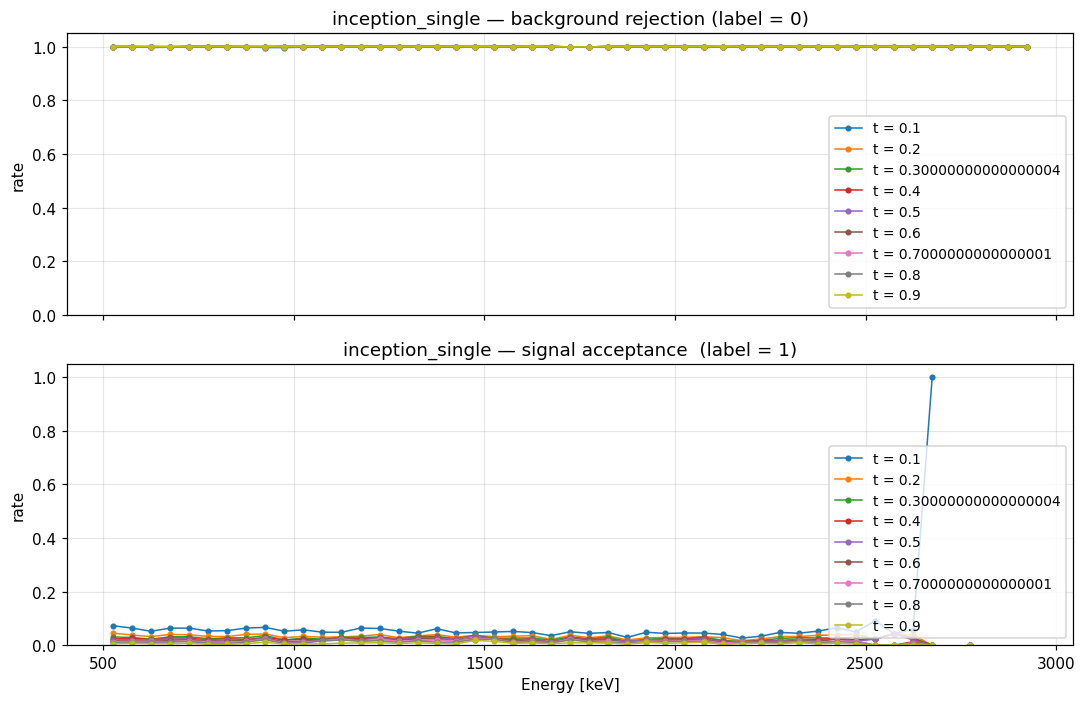

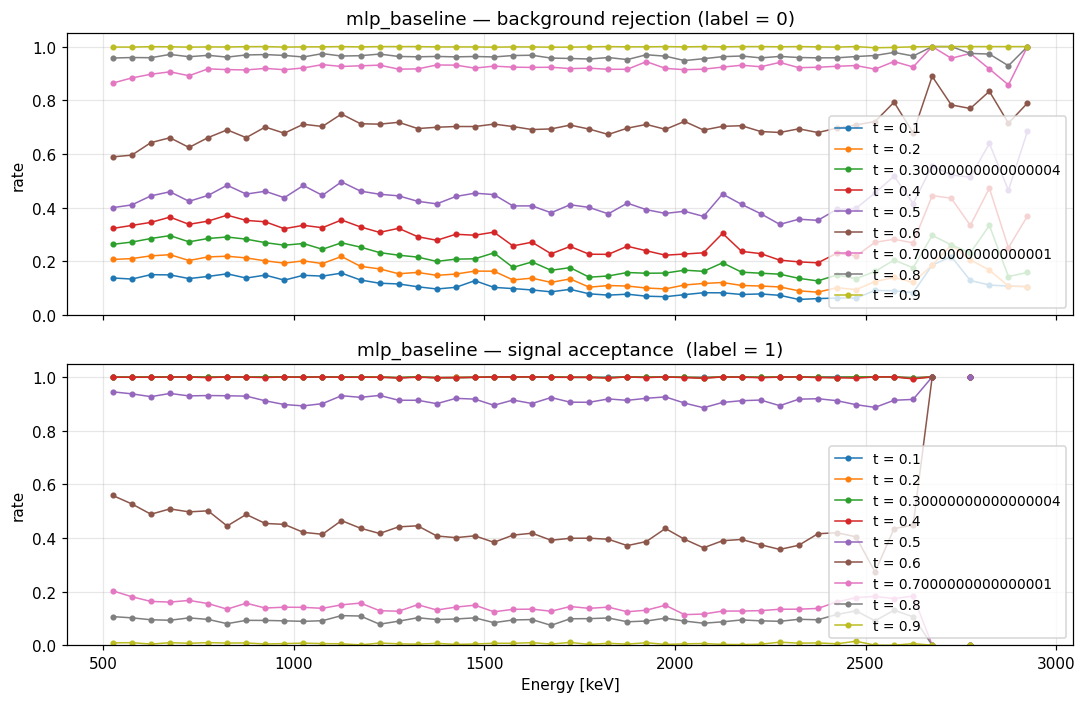

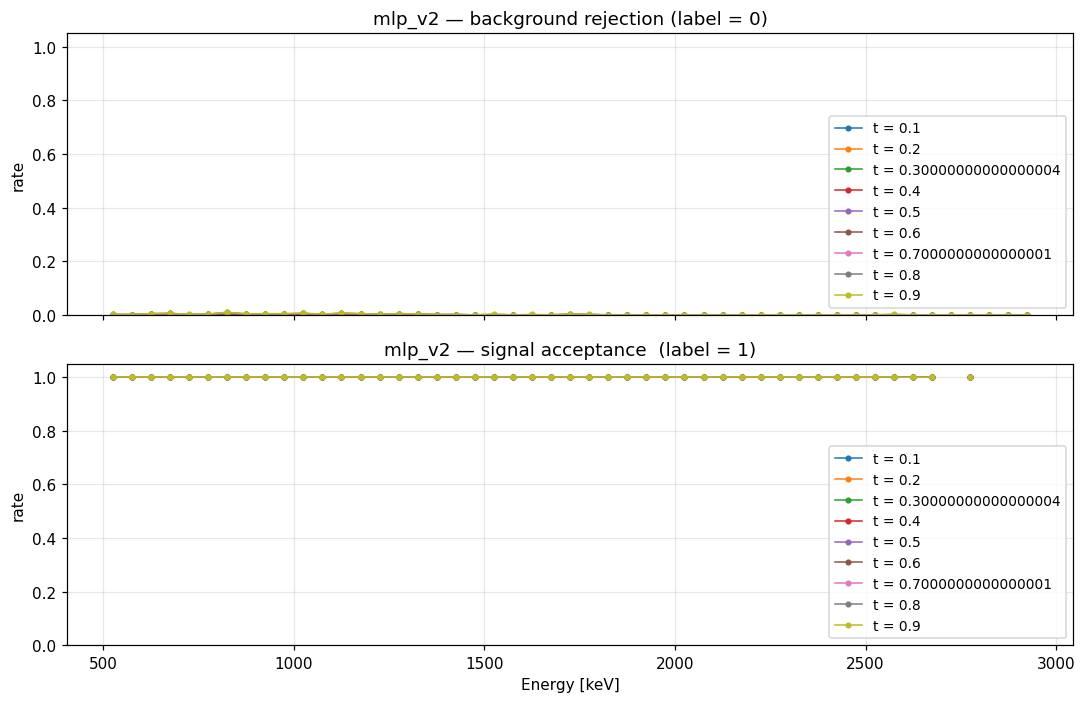

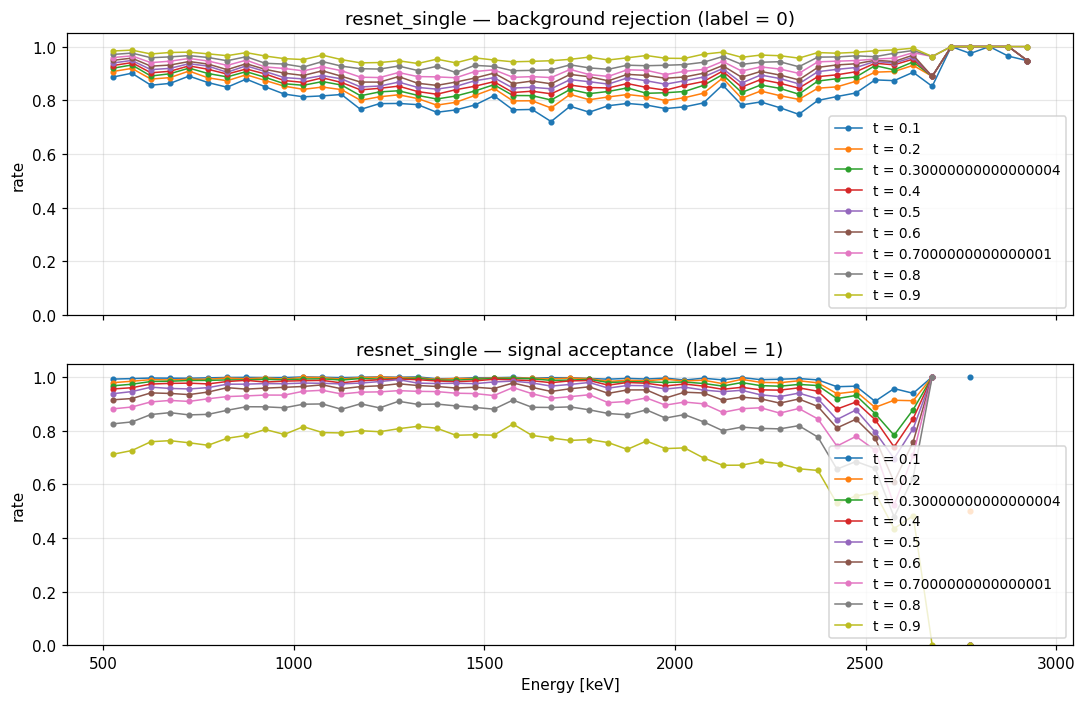

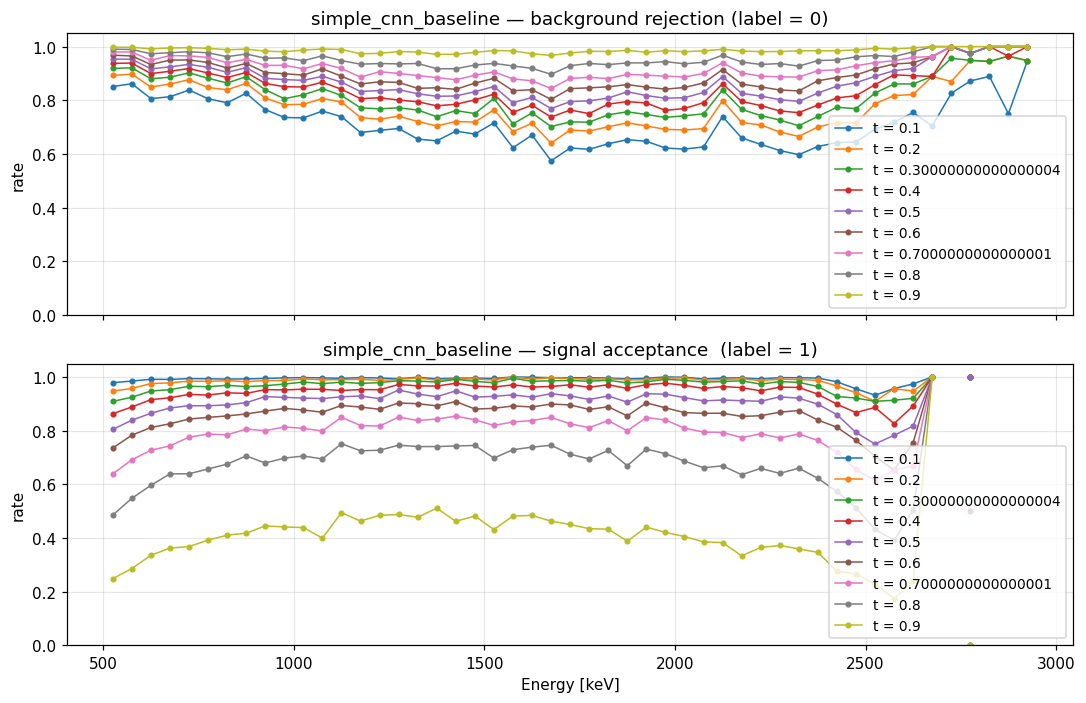

In [18]:
_THRESHOLDS = [0.4, 0.5, 0.6]
_RA_BINS = np.arange(0, 3000, 50)
_RA_CENTERS = 0.5 * (_RA_BINS[:-1] + _RA_BINS[1:])


def _load_predictions_with_energy(run_dir):
    pred_path = run_dir / "eval" / "predictions.h5"
    if not pred_path.is_file():
        return None
    with h5py.File(pred_path, "r") as f:
        return {
            "score": f["score"][:],
            "label": f["label"][:].astype(bool),
            "energy": f["energy"][:],
        }


def _rate_and_err_per_bin(energies, mask, bins):
    """Per-bin rate and binomial standard error sqrt(p*(1-p)/N)."""
    total, _ = np.histogram(energies, bins=bins)
    sel, _ = np.histogram(energies[mask], bins=bins)
    rate = np.divide(
        sel, total,
        out=np.full(total.shape, np.nan, dtype=float),
        where=total > 0,
    )
    err = np.where(
        total > 0,
        np.sqrt(rate * (1.0 - rate) / np.maximum(total, 1)),
        0.0,
    )
    return rate, err


def plot_rejection_acceptance(run):
    preds = _load_predictions_with_energy(run["run_dir"])
    if preds is None:
        print(f"  ({run['name']}: no eval predictions yet — run evaluate first)")
        return

    scores = preds["score"]
    labels = preds["label"]
    energies = preds["energy"]
    is_bkg = ~labels  # label==0 = multi-site, should be rejected
    is_sig = labels   # label==1 = single-site, should be accepted

    fig, (ax_rej, ax_acc) = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)
    palette = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for i, t in enumerate(_THRESHOLDS):
        passed = scores >= t
        color = palette[i % len(palette)]

        rej_rate, rej_err = _rate_and_err_per_bin(
            energies[is_bkg], (~passed)[is_bkg], _RA_BINS
        )
        ax_rej.errorbar(
            _RA_CENTERS, rej_rate, yerr=rej_err,
            fmt="o-", lw=1, ms=3, color=color, label=f"t = {t}",
        )

        acc_rate, acc_err = _rate_and_err_per_bin(
            energies[is_sig], passed[is_sig], _RA_BINS
        )
        ax_acc.errorbar(
            _RA_CENTERS, acc_rate, yerr=acc_err,
            fmt="o-", lw=1, ms=3, color=color, label=f"t = {t}",
        )

    ax_rej.set_title(f"{run['name']} — background rejection (label = 0)")
    ax_acc.set_title(f"{run['name']} — signal acceptance  (label = 1)")
    ax_acc.set_xlabel("Energy [keV]")
    for ax in (ax_rej, ax_acc):
        ax.set_ylabel("rate")
        ax.set_ylim(0, 1.05)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=9, loc="lower right")
    fig.tight_layout()
    plt.show()


if not runs:
    print("No runs found.")
else:
    for r in runs:
        plot_rejection_acceptance(r)


### 8.5 Score distribution by class

For each run, histograms of the model's score (=`sigmoid(logit)`) on
the test set, split by ground-truth label:

* **`label = 0`** — multi-site events that the cut should reject (red).
* **`label = 1`** — single-site events that the cut should accept (blue).

Two views are shown side-by-side:

* **Left** — linear x-axis, log y-axis. Useful for seeing the full
  range and how concentrated each class is.
* **Right** — log x-axis, log y-axis. The score distributions for
  this kind of weighted-BCE classifier are heavily compressed near
  zero, so the log-x view is what makes the class separation visible.

A well-trained classifier shows the two histograms shifted relative to
each other — signal events (blue) sit at higher scores than background
(red). The further apart they are, the more discrimination power.


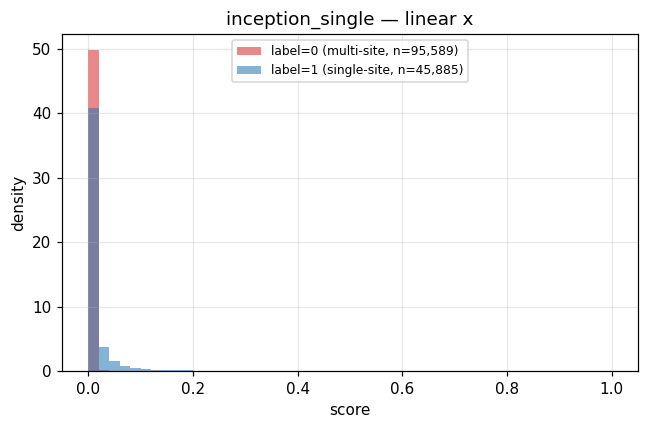

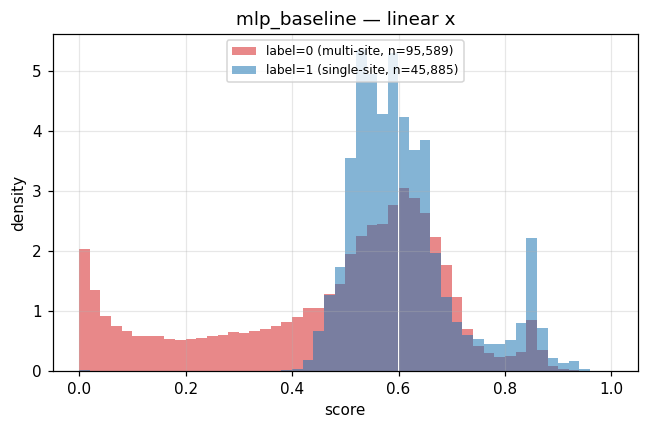

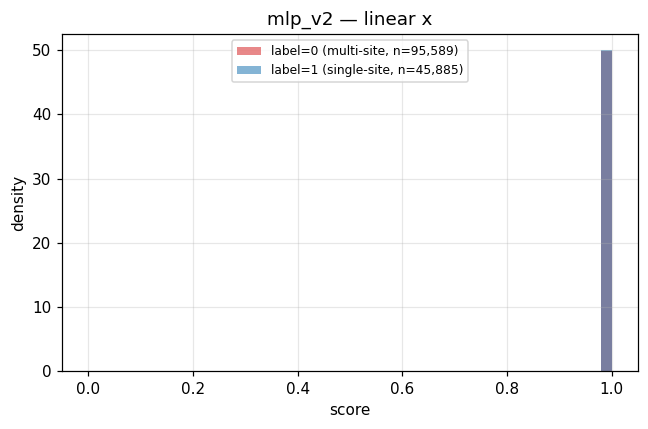

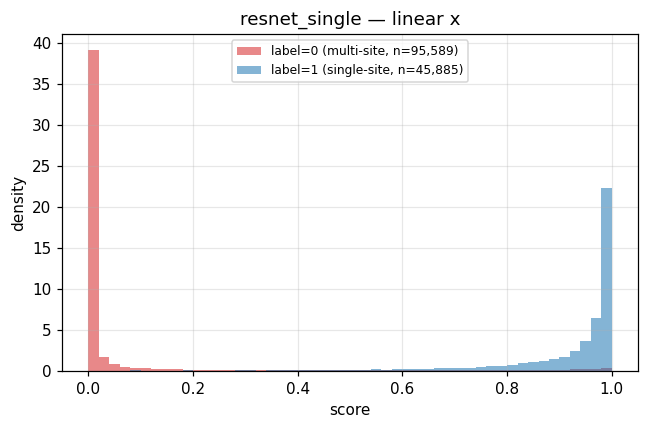

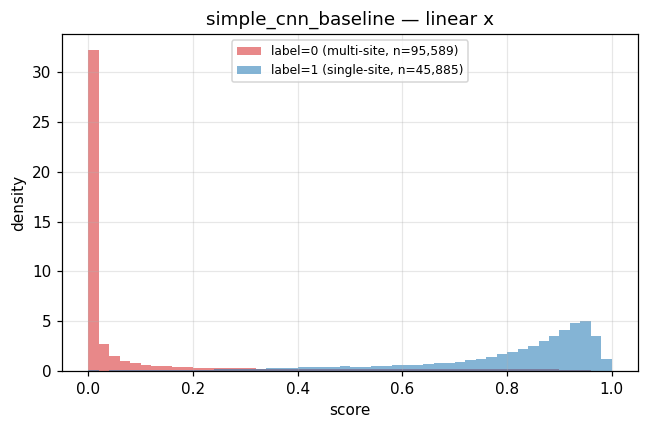

In [19]:
def _load_score_label(run_dir):
    pred_path = run_dir / "eval" / "predictions.h5"
    if not pred_path.is_file():
        return None
    with h5py.File(pred_path, "r") as f:
        return {
            "score": f["score"][:],
            "label": f["label"][:].astype(bool),
        }


def plot_score_distribution(run):
    preds = _load_score_label(run["run_dir"])
    if preds is None:
        print(f"  ({run['name']}: no eval predictions yet — run evaluate first)")
        return

    scores = preds["score"]
    labels = preds["label"]
    bg_scores = scores[~labels]
    sig_scores = scores[labels]

    fig, (ax_lin) = plt.subplots(1, 1, figsize=(6, 4))

    # Linear x, log y.
    
    bins_lin = np.linspace(0.0, 1.0, 51)
    ax_lin.hist(
        bg_scores, bins=bins_lin, density=True, alpha=0.55,
        color="tab:red", label=f"label=0 (multi-site, n={len(bg_scores):,})",
    )
    ax_lin.hist(
        sig_scores, bins=bins_lin, density=True, alpha=0.55,
        color="tab:blue", label=f"label=1 (single-site, n={len(sig_scores):,})",
    )
    #ax_lin.set_yscale("log")
    ax_lin.set_xlabel("score")
    ax_lin.set_ylabel("density")
    ax_lin.set_title(f"{run['name']} — linear x")
    ax_lin.grid(alpha=0.3)
    ax_lin.legend(fontsize=8, loc="upper center")


    fig.tight_layout()
    plt.show()


if not runs:
    print("No runs found.")
else:
    for r in runs:
        plot_score_distribution(r)


### 8.6 Logit-space score distributions (top two models)

The probability-space histograms in 8.5 look heavily compressed
because the **sigmoid function squashes a wide range of logits**
(the model's actual final-layer output) into a tiny probability
range near 0. For ``|logit| > 5`` sigmoid is essentially flat —
so most of the model's discrimination happens at logit values
that map to probabilities so close to zero they pile up in a
single histogram bin.

Inverting the sigmoid (`logit = log(p / (1 - p))`) recovers the
model's underlying output. The class separation that AUC measures
becomes directly visible: the two histograms are *shifted along
the logit axis*, with a clear gap between their medians.

Below, side-by-side probability-space and logit-space
distributions are shown for the **top two models** (`resnet_single`
and `simple_cnn_derivative`). Median lines in the logit panel
highlight the inter-class gap — a wider gap means a stronger
classifier.


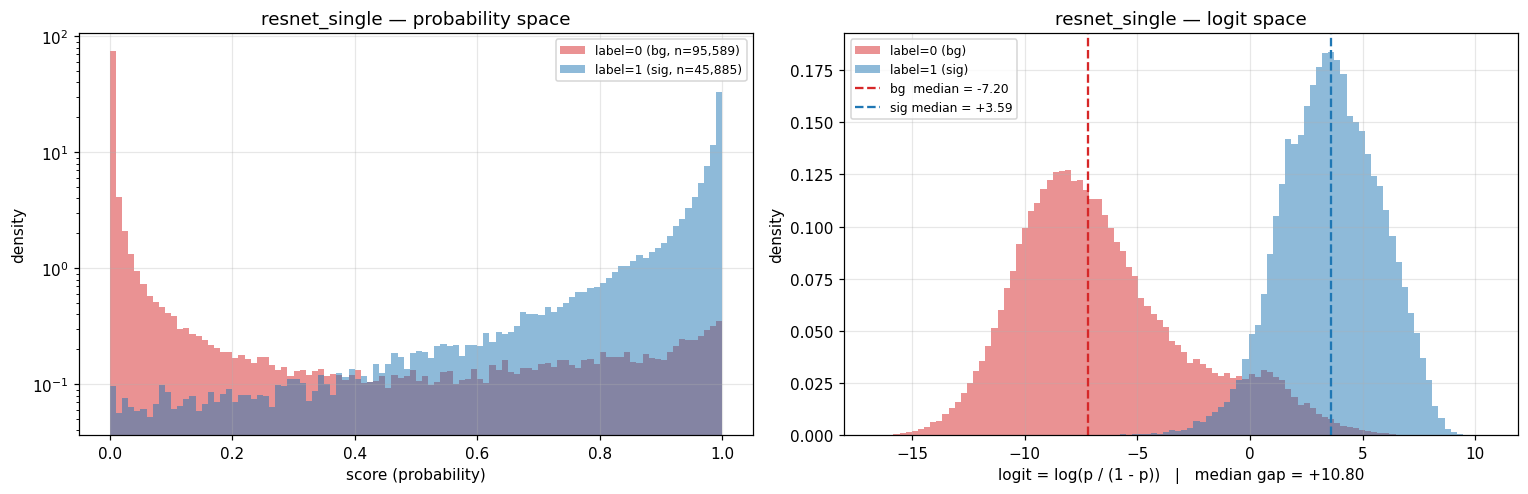

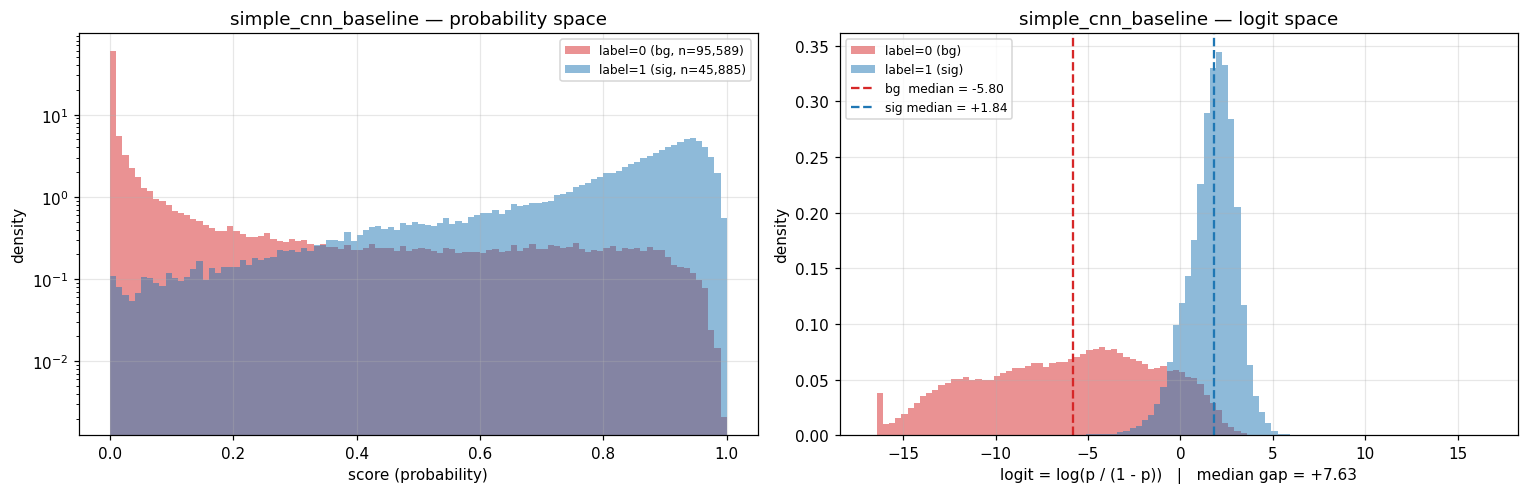

In [20]:
TOP_MODEL_NAMES = ("resnet_single", "simple_cnn_baseline")
_LOGIT_EPS = 1e-7


def _load_score_label_v2(run_dir):
    pred_path = run_dir / "eval" / "predictions.h5"
    if not pred_path.is_file():
        return None
    with h5py.File(pred_path, "r") as f:
        return {
            "score": f["score"][:],
            "label": f["label"][:].astype(bool),
        }


def plot_prob_vs_logit(run):
    preds = _load_score_label_v2(run["run_dir"])
    if preds is None:
        print(f"  ({run['name']}: no eval predictions yet — run evaluate first)")
        return

    score = preds["score"]
    label = preds["label"]
    bg_score = score[~label]
    sig_score = score[label]

    # Sigmoid-inverse, with epsilon clipping to avoid +/- inf.
    safe_bg = np.clip(bg_score, _LOGIT_EPS, 1.0 - _LOGIT_EPS)
    safe_sig = np.clip(sig_score, _LOGIT_EPS, 1.0 - _LOGIT_EPS)
    bg_logit = np.log(safe_bg / (1.0 - safe_bg))
    sig_logit = np.log(safe_sig / (1.0 - safe_sig))

    fig, (ax_p, ax_l) = plt.subplots(1, 2, figsize=(14, 4.6))

    # ---- Probability space (linear x, log y) -----------------
    bins_p = np.linspace(0.0, 1.0, 101)
    ax_p.hist(
        bg_score, bins=bins_p, density=True, alpha=0.5,
        color="tab:red", label=f"label=0 (bg, n={len(bg_score):,})",
    )
    ax_p.hist(
        sig_score, bins=bins_p, density=True, alpha=0.5,
        color="tab:blue", label=f"label=1 (sig, n={len(sig_score):,})",
    )
    ax_p.set_yscale("log")
    ax_p.set_xlabel("score (probability)")
    ax_p.set_ylabel("density")
    ax_p.set_title(f"{run['name']} — probability space")
    ax_p.grid(alpha=0.3)
    ax_p.legend(fontsize=8, loc="upper right")

    # ---- Logit space (overlapping, 100 bins, median lines) ----
    lo = float(min(bg_logit.min(), sig_logit.min()))
    hi = float(max(bg_logit.max(), sig_logit.max()))
    pad = 0.02 * (hi - lo)
    bins_l = np.linspace(lo - pad, hi + pad, 101)
    ax_l.hist(bg_logit, bins=bins_l, density=True, alpha=0.5, color="tab:red", label="label=0 (bg)")
    ax_l.hist(sig_logit, bins=bins_l, density=True, alpha=0.5, color="tab:blue", label="label=1 (sig)")

    bg_med = float(np.median(bg_logit))
    sig_med = float(np.median(sig_logit))
    ax_l.axvline(
        bg_med, color="tab:red", linestyle="--", lw=1.5,
        label=f"bg  median = {bg_med:+.2f}",
    )
    ax_l.axvline(
        sig_med, color="tab:blue", linestyle="--", lw=1.5,
        label=f"sig median = {sig_med:+.2f}",
    )

    gap = sig_med - bg_med
    ax_l.set_xlabel(f"logit = log(p / (1 - p))   |   median gap = {gap:+.2f}")
    ax_l.set_ylabel("density")
    ax_l.set_title(f"{run['name']} — logit space")
    ax_l.grid(alpha=0.3)
    ax_l.legend(fontsize=8, loc="upper left")

    fig.tight_layout()
    plt.show()


_top_runs = [r for r in runs if r["name"] in TOP_MODEL_NAMES]
if not _top_runs:
    print(
        f"None of {TOP_MODEL_NAMES} found among discovered runs. "
        "Train + evaluate them first, then re-run the discovery cell."
    )
else:
    for r in _top_runs:
        plot_prob_vs_logit(r)


### 8.7 Run Comparison Table

A row per run with the configuration knobs most likely to differ between
experiments and the final-epoch metrics. Useful as a one-glance
leaderboard.


In [21]:
if not runs:
    print("No runs found.")
else:
    rows = []
    for r in runs:
        cfg = r["metadata"]["config"]
        final = r["history"][-1] if r["history"] else {}
        rows.append(
            {
                "name": r["name"],
                "model": cfg["model"]["name"],
                "model_params": json.dumps(cfg["model"]["params"], separators=(",", ":")),
                "optimizer": cfg["optim"]["optimizer"],
                "lr": cfg["optim"]["lr"],
                "loss_type": cfg["loss"]["type"],
                "balanced_sampler": cfg["loss"]["balanced_sampler"],
                "epochs": r["metadata"]["completed_epochs"],
                "final_train_loss": final.get("train_loss"),
                "final_test_loss": final.get("test_loss"),
                "final_test_auc": final.get("test_roc_auc"),
            }
        )
    df = pd.DataFrame(rows)
    # Sort by final_test_auc descending (best first), NaN last.
    if "final_test_auc" in df:
        df = df.sort_values("final_test_auc", ascending=False, na_position="last")
    df.style.format(
        {
            "lr": "{:.2e}",
            "final_train_loss": "{:.4f}",
            "final_test_loss": "{:.4f}",
            "final_test_auc": "{:.4f}",
        }
    )


## 9. Summary and Next Steps

What we confirmed in this notebook:

- The Zenodo partial release is fully on disk at `/home/klz/Data/MAJORANA/`.
- One `Train` file holds 65 000 events with 10 parallel arrays; waveforms
  are `(65000, 3800) float64` — about 1.85 GB per file.
- Reading a full file into memory takes a few seconds; random-access reads
  of 1000 waveforms are sub-second.
- The energy spectrum and per-cut pass rates qualitatively reproduce the
  paper's Figure 2 even on a single chunk.

Reasonable next steps:

1. Build a `torch.utils.data.Dataset` that opens an HDF5 file lazily inside
   each DataLoader worker (avoiding the `fork()` issue with `h5py`).
2. Decide on a normalization scheme for waveforms (per-event baseline
   subtraction? global mean/std? rising-edge alignment using `tp0`?).
3. Sketch a research direction — what task are we *actually* solving with
   these waveforms?
